## Participantes do grupo:

### - Natã Lino RA: 2038878

### - Murilo Basílio RA: 2066677

### - Felipe Ribeiro RA: 2028059

### **Total Bilirubin**

Pigmento resultante da quebra de glóbulos vermelhos, processado pelo fígado. Valores altos podem indicar doença hepática, obstrução biliar ou icterícia.
**Referência:** até **1.2 mg/dL**

### **Direct Bilirubin**

Forma conjugada da bilirrubina, pronta para eliminação pela bile. Elevação sugere problemas no fígado ou vias biliares.
**Referência:** até **0.3 mg/dL**

### **Alkaline Phosphotase**

Enzima presente principalmente no fígado e ossos. Valores altos podem indicar colestase ou doenças ósseas.

### **Alamine Aminotransferase (ALT)**

Enzima encontrada no fígado. Aumenta quando há lesão hepática.
**Referência:** **7 a 56 U/L**

### **Aspartate Aminotransferase (AST)**

Enzima presente no fígado, músculos e coração. Valores altos podem indicar dano hepático ou muscular.
**Referência:** **5 a 40 U/L**

### **Total Proteins**

Soma das proteínas do sangue, principalmente albumina e globulinas. Avalia estado nutricional e função hepática.

### **Albumin**

Principal proteína produzida pelo fígado. Mantém líquidos no sangue e transporta substâncias. Valores baixos podem indicar doença hepática, renal ou desnutrição.
**Referência:** **3.5 a 5.0 g/dL**

### **Albumin and Globulin Ratio (A/G)**

Relação entre albumina e globulinas. Alterações podem indicar inflamação, doenças hepáticas ou renais.
**Referência:** **1.0 a 2.5**


# Download do dataset

In [43]:
import kagglehub

path = kagglehub.dataset_download("uciml/indian-liver-patient-records")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'indian-liver-patient-records' dataset.
Path to dataset files: /kaggle/input/indian-liver-patient-records


# Imports

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Tratamento e visualização do dataset

In [45]:
df = pd.read_csv(os.path.join(path, "indian_liver_patient.csv"))

print(df.head())
print(df.info())
print(df.isnull().sum())

df.columns = [
    'Idade',
    'Genero',
    'Bilirrubina_Total',
    'Bilirrubina_Direta',
    'Fosfatase_Alcalina',
    'ALT',
    'AST',
    'Proteina_Total',
    'Albumina',
    'Relacao_A_G',
    'Classe'
]

for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

df['Genero'] = df['Genero'].str.strip().str.capitalize()

df['Genero'] = df['Genero'].map({
    'Male': 1,
    'Female': 0
})

df['Classe'] = df['Classe'].replace({
    1: 1,
    2: 0
})

print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print(df.duplicated().sum())

colunas_numericas = df.drop('Classe', axis=1).columns

for col in colunas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], limite_inf, limite_sup)

print(df.isnull().sum())
print(df.dtypes)
print(df['Classe'].value_counts())
print(df.shape)

print(df.head())

   Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0   65  Female              0.7               0.1                   187   
1   62    Male             10.9               5.5                   699   
2   62    Male              7.3               4.1                   490   
3   58    Male              1.0               0.4                   182   
4   72    Male              3.9               2.0                   195   

   Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Protiens  \
0                        16                          18             6.8   
1                        64                         100             7.5   
2                        60                          68             7.0   
3                        14                          20             6.8   
4                        27                          59             7.3   

   Albumin  Albumin_and_Globulin_Ratio  Dataset  
0      3.3                        0.90        1 

/tmp/ipykernel_1259/2139528779.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


# Grafico de Distribuição



DISTRIBUIÇÃO DE VARIAVEIS



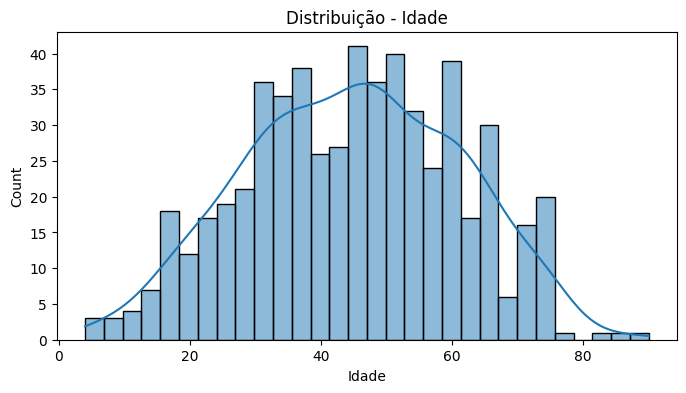

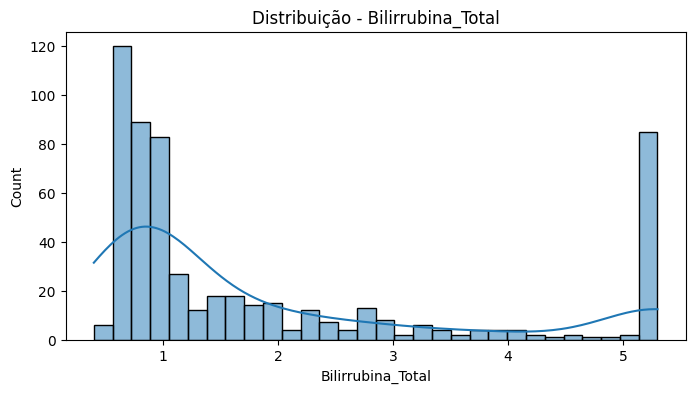

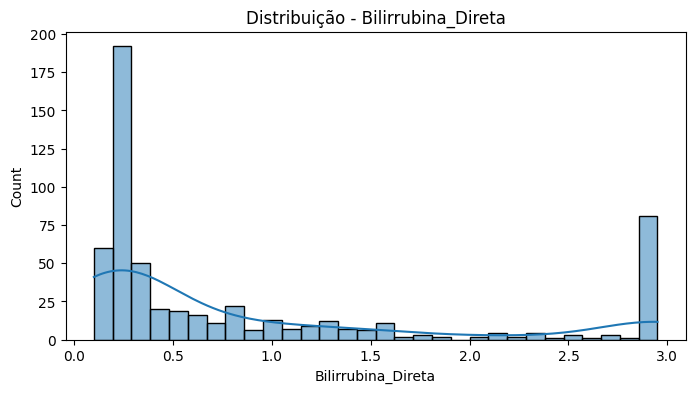

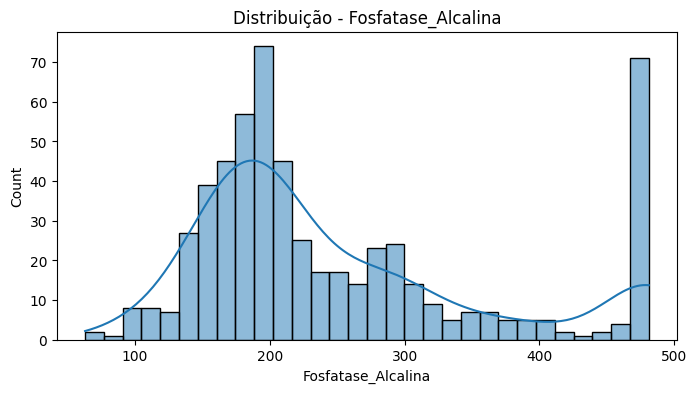

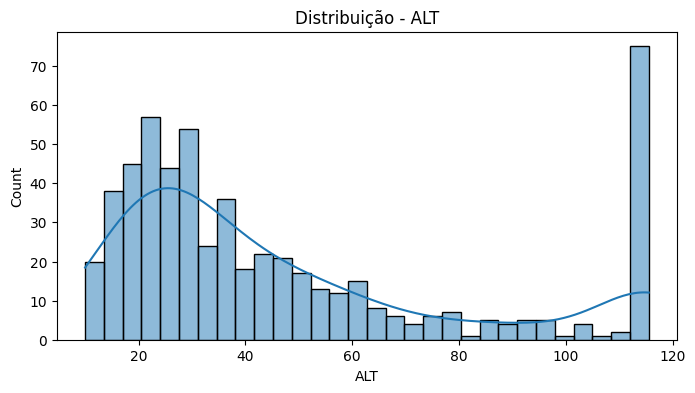

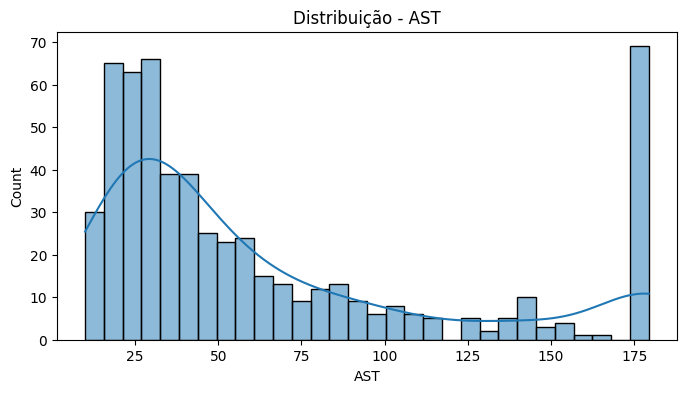

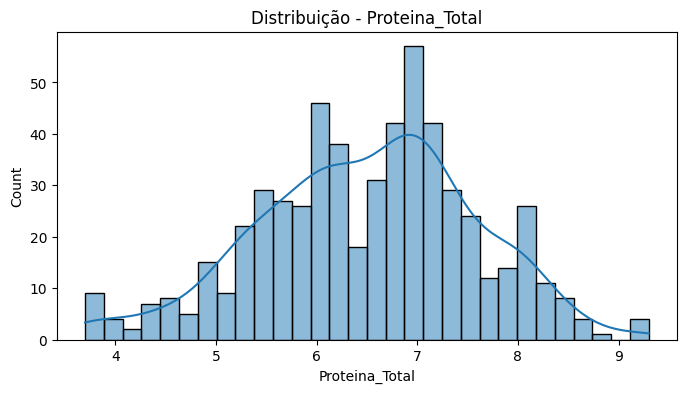

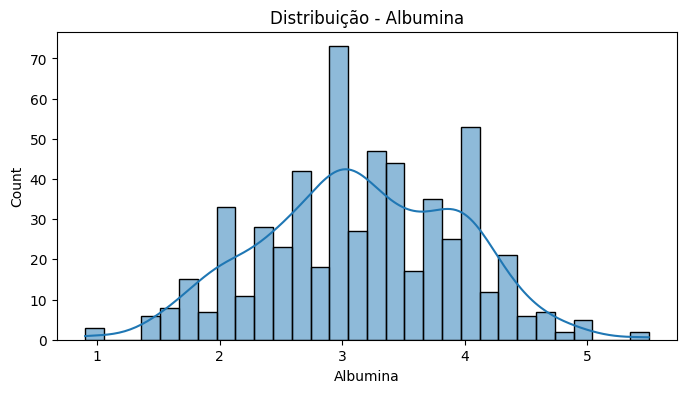

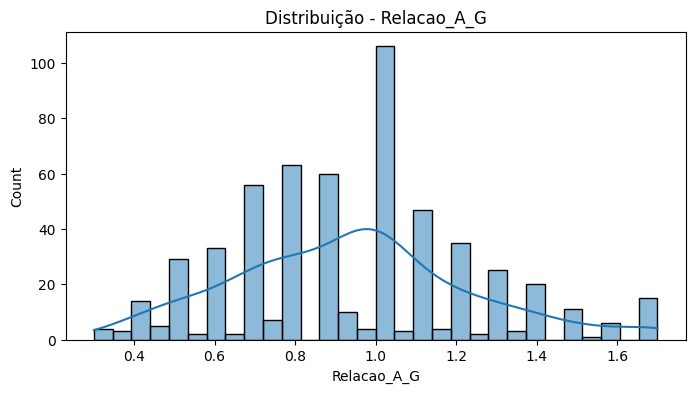

In [46]:
print("\n")
print("=" * 30)
print("DISTRIBUIÇÃO DE VARIAVEIS")
print("=" * 30, "\n")


variaveis = [
    'Idade',
    'Bilirrubina_Total',
    'Bilirrubina_Direta',
    'Fosfatase_Alcalina',
    'ALT',
    'AST',
    'Proteina_Total',
    'Albumina',
    'Relacao_A_G'
]

for coluna in variaveis:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[coluna],
        kde=True,
        bins=30
    )

    plt.title(f'Distribuição - {coluna}')
    plt.show()

#Analise de Outliers



ANALISE OUTLIERS



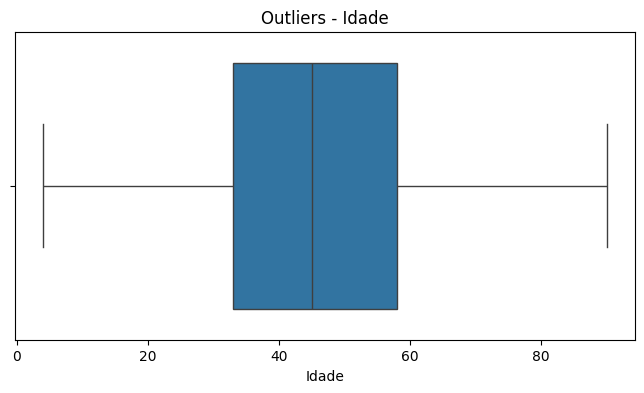

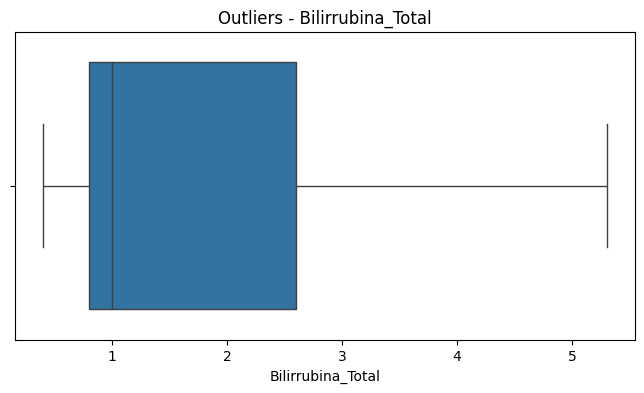

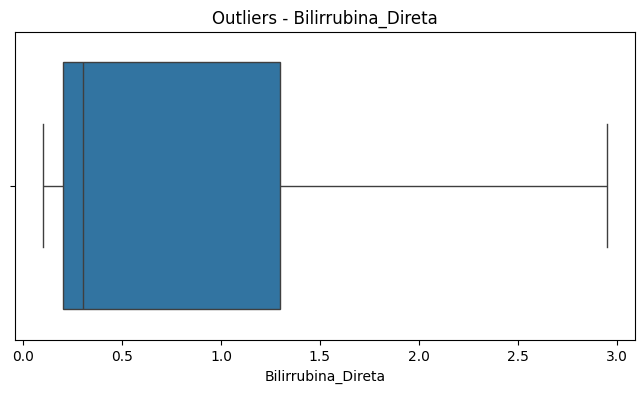

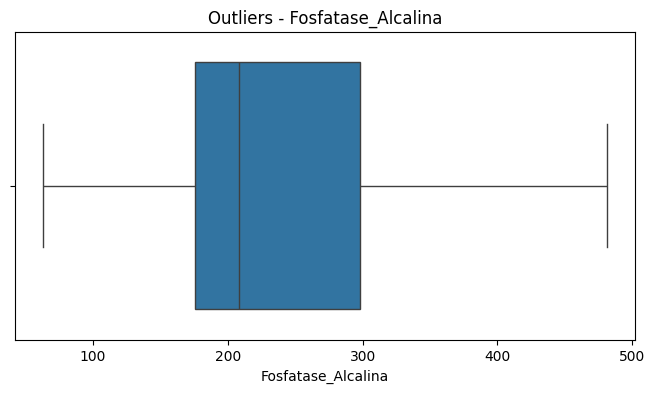

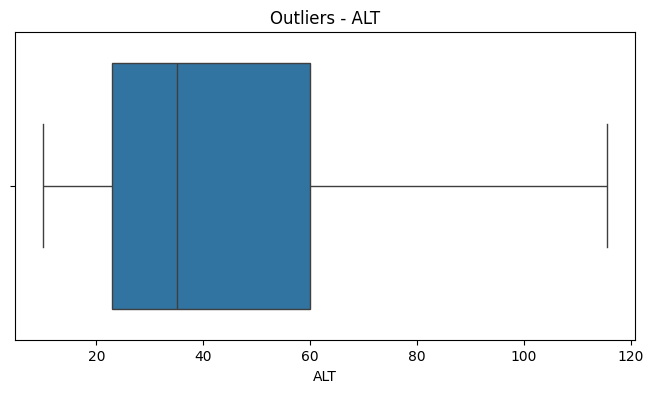

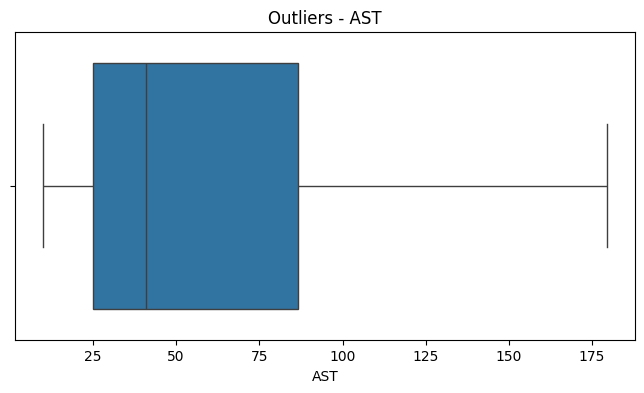

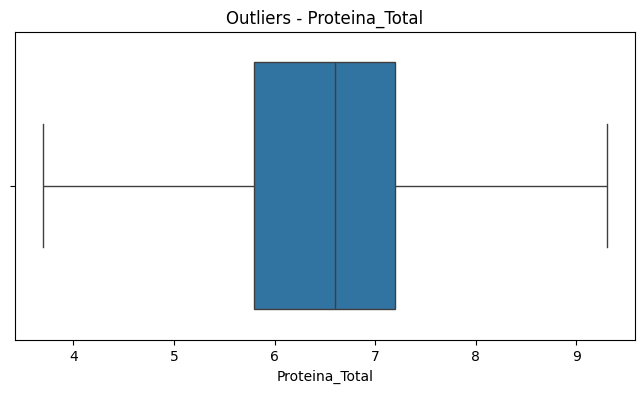

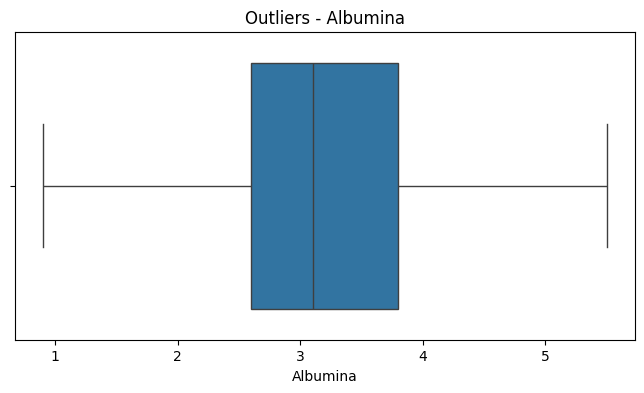

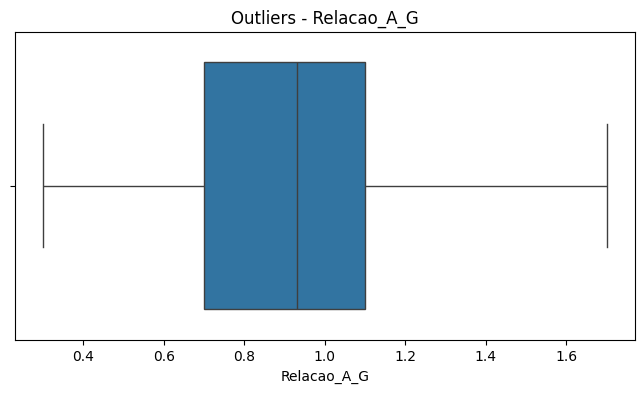

<Axes: xlabel='Genero', ylabel='count'>

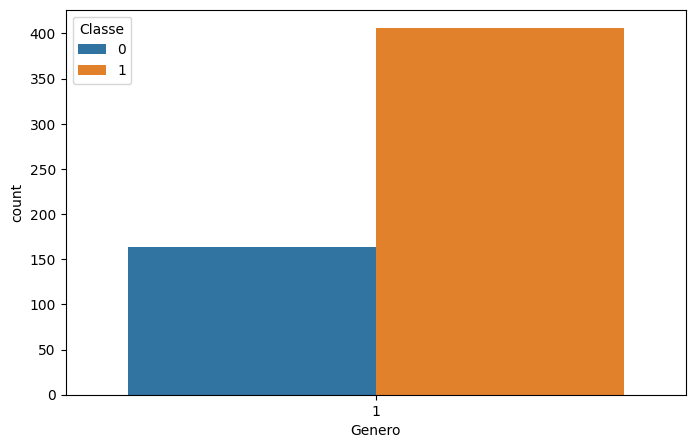

In [47]:
print("\n")
print("=" * 30)
print("ANALISE OUTLIERS")
print("=" * 30, "\n")


# BOXPLOTS (OUTLIERS)
for coluna in variaveis:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[coluna]
    )

    plt.title(f'Outliers - {coluna}')

    plt.show()

plt.figure(figsize=(8,5))

sns.countplot(
    x='Genero',
    hue='Classe',
    data=df
)

#EDA

In [48]:
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())

   Idade  Genero  Bilirrubina_Total  Bilirrubina_Direta  Fosfatase_Alcalina  \
0     65       1                0.7                0.10                 187   
1     62       1                5.3                2.95                 481   
2     62       1                5.3                2.95                 481   
3     58       1                1.0                0.40                 182   
4     72       1                3.9                2.00                 195   

    ALT    AST  Proteina_Total  Albumina  Relacao_A_G  Classe  
0  16.0   18.0             6.8       3.3         0.90       1  
1  64.0  100.0             7.5       3.2         0.74       1  
2  60.0   68.0             7.0       3.3         0.89       1  
3  14.0   20.0             6.8       3.4         1.00       1  
4  27.0   59.0             7.3       2.4         0.40       1  
<class 'pandas.core.frame.DataFrame'>
Index: 570 entries, 0 to 582
Data columns (total 11 columns):
 #   Column              Non-Null Count  

#Correlação



CORRELAÇÃO



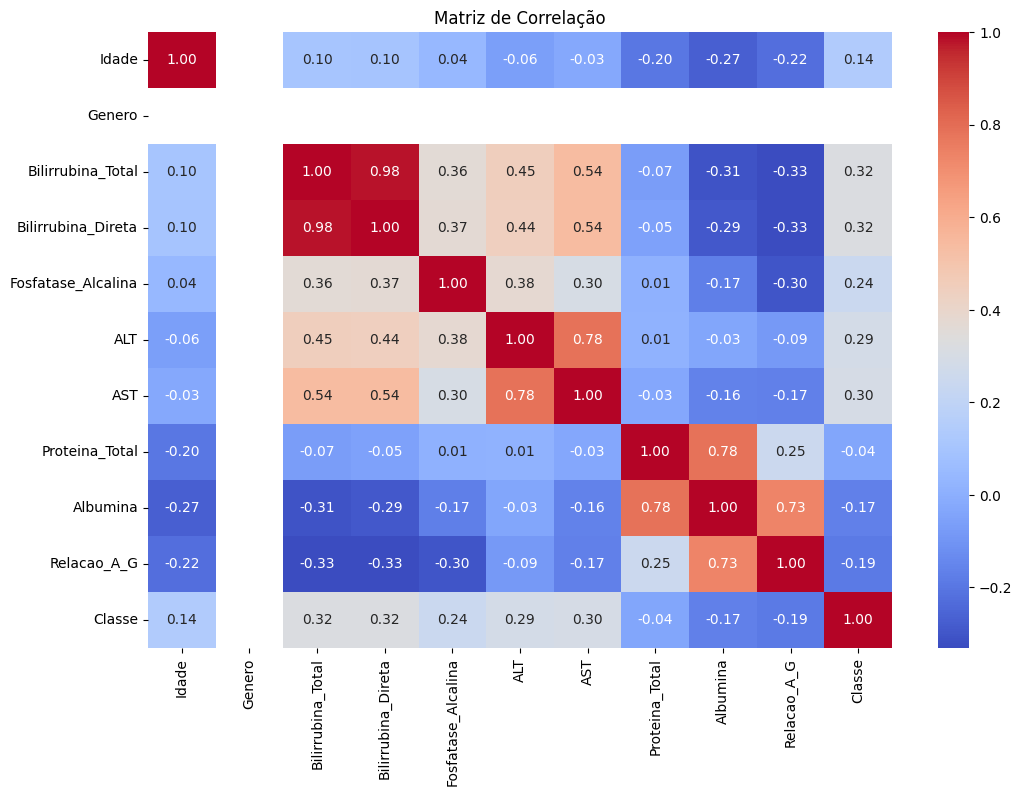

In [49]:
print("\n")
print("=" * 30)
print("CORRELAÇÃO")
print("=" * 30, "\n")

# CORRELAÇÃO
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de Correlação')

plt.show()

#Análise por gênero



ANALISE POR GÊNERO



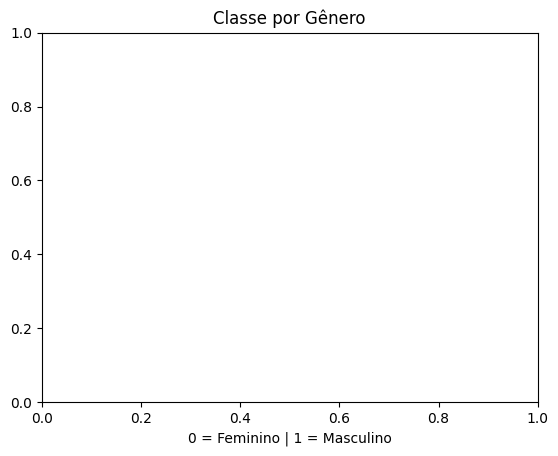

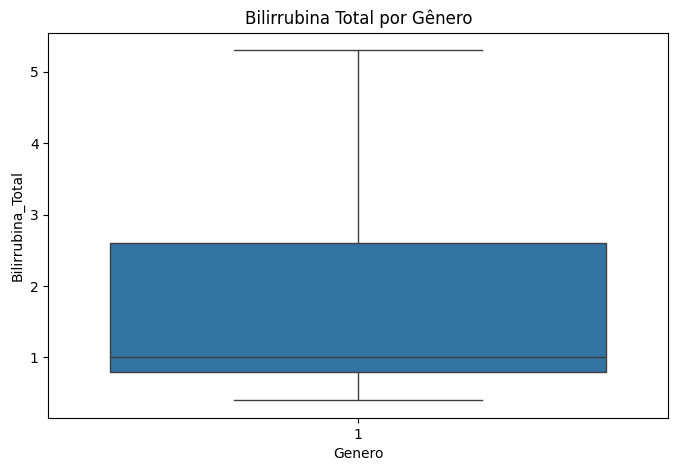

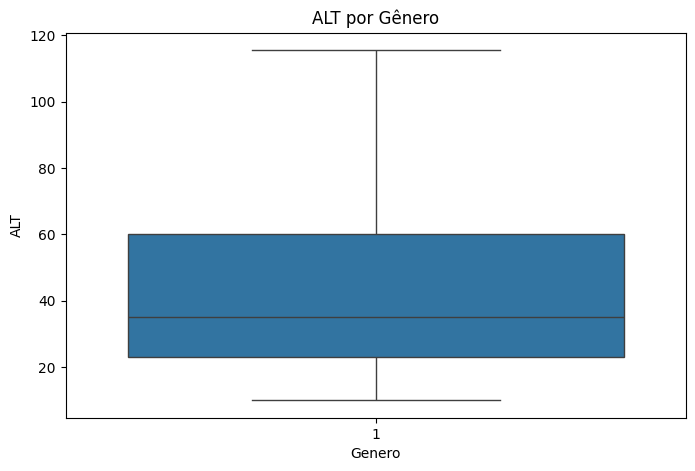

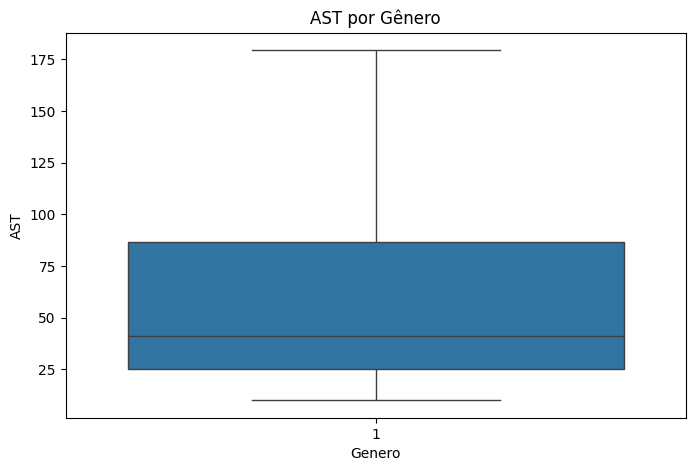

In [50]:
print("\n")
print("=" * 30)
print("ANALISE POR GÊNERO")
print("=" * 30, "\n")

# ANÁLISE POR GÊNERO
plt.title('Classe por Gênero')

plt.xlabel('0 = Feminino | 1 = Masculino')

plt.show()

# Bilirrubina por gênero
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Genero',
    y='Bilirrubina_Total',
    data=df
)

plt.title('Bilirrubina Total por Gênero')

plt.show()

# ALT por gênero
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Genero',
    y='ALT',
    data=df
)

plt.title('ALT por Gênero')

plt.show()

# AST por gênero
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Genero',
    y='AST',
    data=df
)

plt.title('AST por Gênero')

plt.show()

# Treino, validação e teste

In [51]:
X = df.drop('Classe', axis=1)
y = df['Classe']

x_train, x_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

# Modelos
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}


# Analise Exploratória

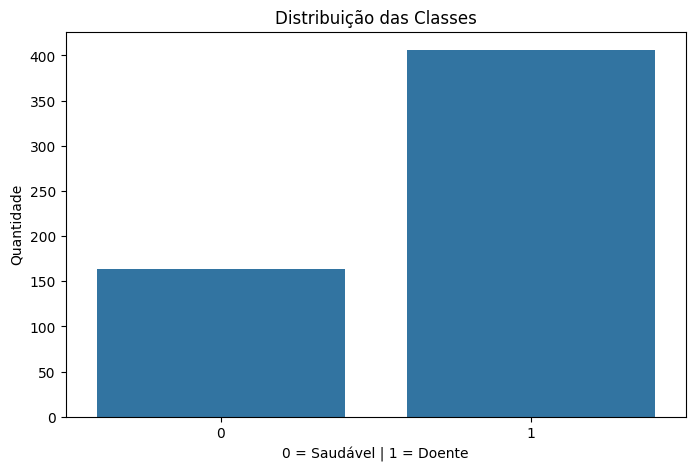

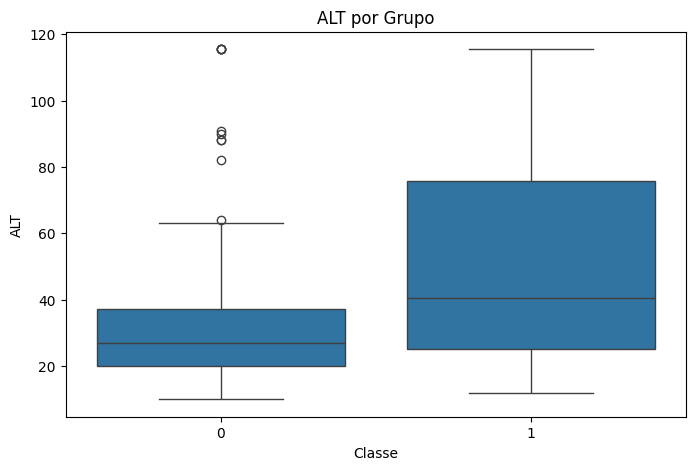

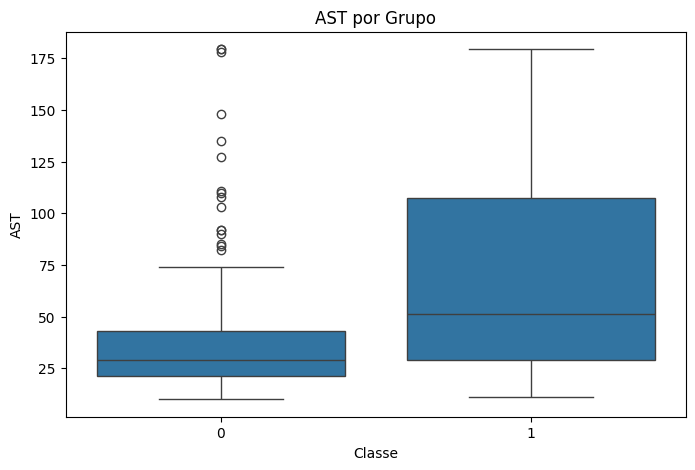

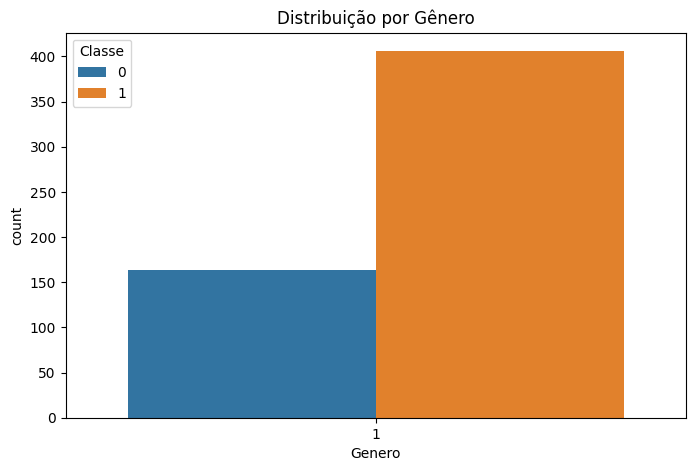

In [52]:
# Distribuiçao das classes
plt.figure(figsize=(8,5))
sns.countplot(x='Classe', data=df)
plt.title("Distribuição das Classes")
plt.xlabel("0 = Saudável | 1 = Doente")
plt.ylabel("Quantidade")
plt.show()

# Enzimasw por grupo
plt.figure(figsize=(8,5))
sns.boxplot(x='Classe', y='ALT', data=df)
plt.title("ALT por Grupo")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Classe', y='AST', data=df)
plt.title("AST por Grupo")
plt.show()

# Por genro
plt.figure(figsize=(8,5))
sns.countplot(x='Genero', hue='Classe', data=df)
plt.title("Distribuição por Gênero")
plt.show()

#Testes:

### Stratified K-fold


In [53]:
resultados = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nome, modelo in models.items():

    scores = cross_validate(
        modelo,
        x_train,
        y_train,
        cv=cv,
        scoring=['accuracy','precision','recall','f1','roc_auc']
    )

    resultados.append({
        "Classificador": nome,
        "Acurácia": scores['test_accuracy'].mean(),
        "Precisão": scores['test_precision'].mean(),
        "Recall": scores['test_recall'].mean(),
        "F1-Score": scores['test_f1'].mean(),
        "AUC-ROC": scores['test_roc_auc'].mean()
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados)

         Classificador  Acurácia  Precisão    Recall  F1-Score   AUC-ROC
0  Logistic Regression  0.716741  0.746496  0.911779  0.820613  0.738877
1        Random Forest  0.691677  0.747814  0.855451  0.797640  0.715394
2    Gradient Boosting  0.656582  0.732772  0.813283  0.770755  0.660992


### Matriz de confusão

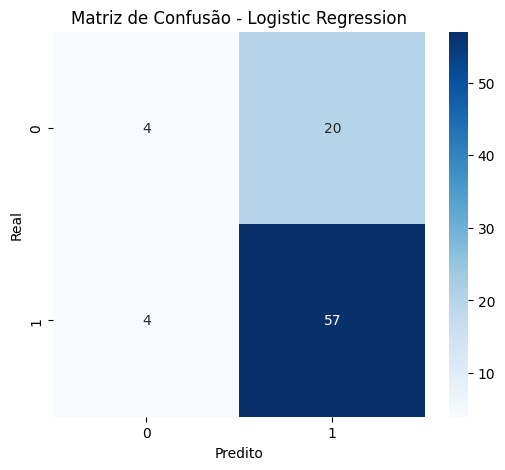

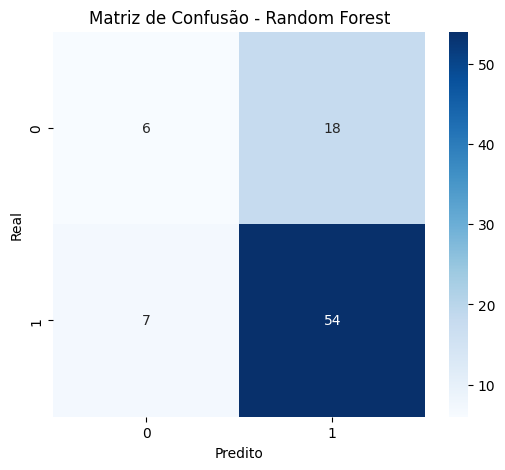

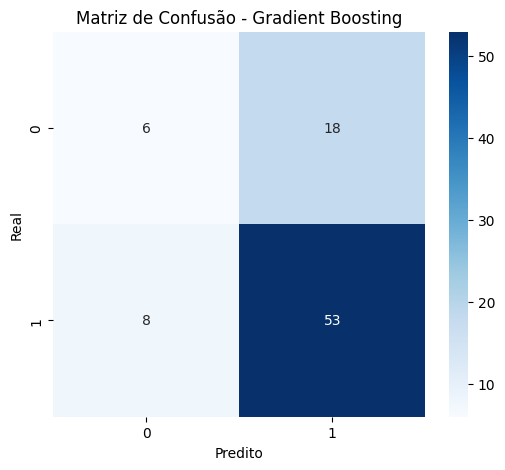

         Classificador  Acurácia  Precisão    Recall  F1-Score   AUC-ROC
0  Logistic Regression  0.729272  0.755205  0.918985  0.828514  0.739392
2    Gradient Boosting  0.709335  0.754571  0.876817  0.811033  0.699687
1        Random Forest  0.706835  0.749953  0.884023  0.810843  0.713989


In [54]:
for nome, modelo in models.items():

    modelo.fit(x_train, y_train)

    y_pred = modelo.predict(x_val)

    cm = confusion_matrix(y_val, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de Confusão - {nome}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()

resultados = []

for nome, modelo in models.items():

    scores = cross_validate(
        modelo,
        x_train,
        y_train,
        cv=5,
        scoring=[
            'accuracy',
            'precision',
            'recall',
            'f1',
            'roc_auc'
        ]
    )

    resultados.append({
        "Classificador": nome,
        "Acurácia": scores['test_accuracy'].mean(),
        "Precisão": scores['test_precision'].mean(),
        "Recall": scores['test_recall'].mean(),
        "F1-Score": scores['test_f1'].mean(),
        "AUC-ROC": scores['test_roc_auc'].mean()
    })

df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    by="Acurácia",
    ascending=False
)

print(df_resultados)

### Curvas ROC / AUC

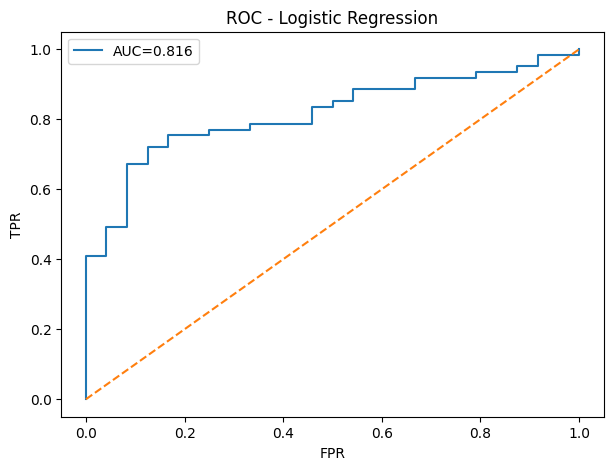

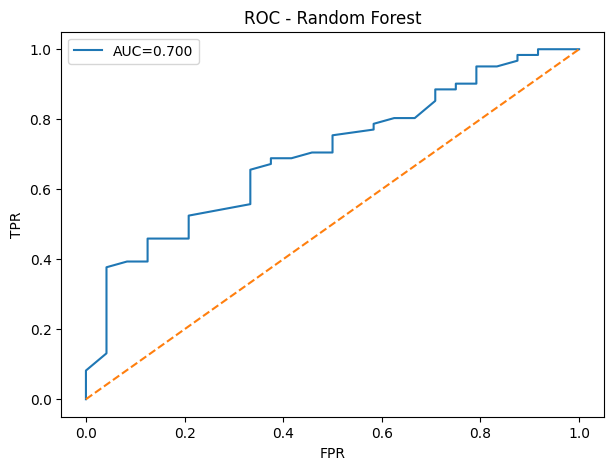

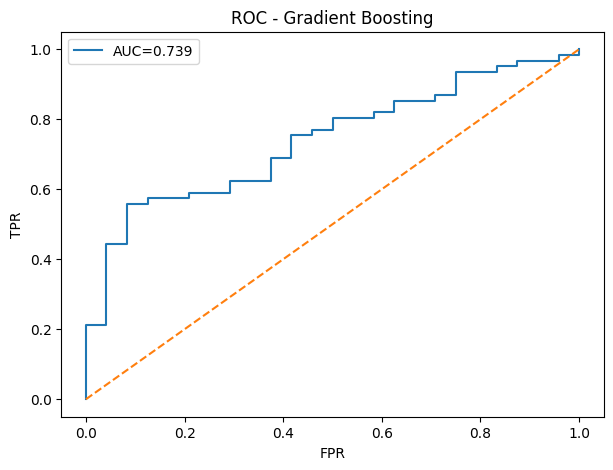

         Classificador  Acurácia  Precisão    Recall  F1-Score   AUC-ROC
0  Logistic Regression  0.717647  0.740260  0.934426  0.826087  0.816257
2    Gradient Boosting  0.694118  0.746479  0.868852  0.803030  0.739071
1        Random Forest  0.705882  0.750000  0.885246  0.812030  0.700478


In [55]:
for nome, modelo in models.items():

    modelo.fit(x_train, y_train)

    y_proba = modelo.predict_proba(x_val)[:,1]

    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc = roc_auc_score(y_val, y_proba)

    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.title(f"ROC - {nome}")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.show()

    resultados_roc = []

for nome, modelo in models.items():

    modelo.fit(x_train, y_train)

    y_pred = modelo.predict(x_val)
    y_proba = modelo.predict_proba(x_val)[:, 1]

    resultados_roc.append({
        "Classificador": nome,
        "Acurácia": accuracy_score(y_val, y_pred),
        "Precisão": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-Score": f1_score(y_val, y_pred),
        "AUC-ROC": roc_auc_score(y_val, y_proba)
    })

df_roc = pd.DataFrame(resultados_roc).sort_values(
    by="AUC-ROC",
    ascending=False
)

print(df_roc)

## Melhorias:

### 1. Grafico de distribuição
### 2. Analise de Outliers
### 3. EDA
### 4. Correlação
### 5. Análise por gênero
### Importante: Melhoria no relatorio

# Salvamento do modelo para o Streamlit

Esta etapa mantém a abordagem anterior do notebook, sem `Pipeline`. Por isso, o modelo e o `StandardScaler` são salvos separadamente. O Streamlit precisa carregar os dois arquivos: primeiro aplica o scaler nos dados digitados pelo usuário e depois chama o modelo treinado.


In [56]:
import json
import joblib
from pathlib import Path
from sklearn.base import clone
from sklearn.metrics import classification_report

# Pastas esperadas na estrutura do GitHub/Streamlit.
# Se o notebook for executado dentro da pasta notebooks, volta uma pasta
# para salvar em p2/model e p2/data.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODEL_DIR = PROJECT_ROOT / "model"
DATA_DIR = PROJECT_ROOT / "data"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Usa a tabela de validação por AUC-ROC para escolher o melhor classificador.
# *Possível alterar de "AUC-ROC" para "F1-Score", "Recall" ou "Acurácia".
criterio_escolha = "AUC-ROC"
df_modelos_validacao = df_roc.sort_values(by=criterio_escolha, ascending=False).reset_index(drop=True)
melhor_nome = df_modelos_validacao.loc[0, "Classificador"]

print("Melhor modelo selecionado:", melhor_nome)
print(df_modelos_validacao)

# Como x_train, x_val e x_test já foram normalizados anteriormente com StandardScaler,
# juntamos treino + validação já transformados para treinar a versão final.
x_treino_final = np.vstack([x_train, x_val])
y_treino_final = pd.concat([y_train, y_val])

modelo_final = clone(models[melhor_nome])
modelo_final.fit(x_treino_final, y_treino_final)

y_pred_teste = modelo_final.predict(x_test)
y_proba_teste = modelo_final.predict_proba(x_test)[:, 1]

metricas_teste = {
    "Acurácia": accuracy_score(y_test, y_pred_teste),
    "Precisão": precision_score(y_test, y_pred_teste),
    "Recall": recall_score(y_test, y_pred_teste),
    "F1-Score": f1_score(y_test, y_pred_teste),
    "AUC-ROC": roc_auc_score(y_test, y_proba_teste),
}

print("\nMétricas finais no conjunto de teste:")
print(pd.DataFrame([metricas_teste]))

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_teste))

# Salva modelo e scaler separadamente, pois a versão sem Pipeline depende dos dois.
joblib.dump(modelo_final, MODEL_DIR / "modelo_final.joblib")
joblib.dump(scaler, MODEL_DIR / "scaler.joblib")

metadata = {
    "melhor_modelo": melhor_nome,
    "criterio_escolha": criterio_escolha,
    "features": list(X.columns),
    "mapeamento_genero": {"Feminino": 0, "Masculino": 1},
    "mapeamento_classe": {
        "0": "Sem indicativo de doença hepática",
        "1": "Possível indicativo de doença hepática",
    },
    "metricas_teste": metricas_teste,
    "observacao": "Modelo salvo sem Pipeline; o app deve aplicar model/scaler.joblib antes da predição.",
}

with open(MODEL_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

df.to_csv(DATA_DIR / "dataset.csv", index=False)

print("\nArquivos gerados:")
print(MODEL_DIR / "modelo_final.joblib")
print(MODEL_DIR / "scaler.joblib")
print(MODEL_DIR / "metadata.json")
print(DATA_DIR / "dataset.csv")

Melhor modelo selecionado: Logistic Regression
         Classificador  Acurácia  Precisão    Recall  F1-Score   AUC-ROC
0  Logistic Regression  0.717647  0.740260  0.934426  0.826087  0.816257
1    Gradient Boosting  0.694118  0.746479  0.868852  0.803030  0.739071
2        Random Forest  0.705882  0.750000  0.885246  0.812030  0.700478

Métricas finais no conjunto de teste:
   Acurácia  Precisão    Recall  F1-Score   AUC-ROC
0   0.72093  0.760563  0.885246  0.818182  0.742295

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.53      0.32      0.40        25
           1       0.76      0.89      0.82        61

    accuracy                           0.72        86
   macro avg       0.65      0.60      0.61        86
weighted avg       0.69      0.72      0.70        86


Arquivos gerados:
/content/model/modelo_final.joblib
/content/model/scaler.joblib
/content/model/metadata.json
/content/data/dataset.csv
